# 04 — Exploratory Data Analysis

Univariate, bivariate, and multivariate EDA on the cleaned, feature-engineered
application data — the analytical backbone behind the Streamlit pages.
No predictive modeling anywhere in this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("..")

from utils.preprocessing import clean_application_data
from utils.feature_engineering import add_application_features
from utils.metrics import descriptive_stats, default_rate_by, correlation_with_target, top_bottom_by_default_rate

app = pd.read_csv("../data/application_train.csv")
df = add_application_features(clean_application_data(app))
df.shape

(1000, 138)

## Univariate analysis

In [2]:
descriptive_stats(df["AMT_INCOME_TOTAL"])

{'Mean': np.float64(167660.48),
 'Median': np.float64(144000.0),
 'Mode': np.float64(112500.0),
 'Std Dev': np.float64(90167.63),
 'Minimum': np.float64(31500.0),
 'Maximum': np.float64(765000.0),
 '25th Percentile': np.float64(112500.0),
 '75th Percentile': np.float64(202500.0),
 'IQR': np.float64(90000.0)}

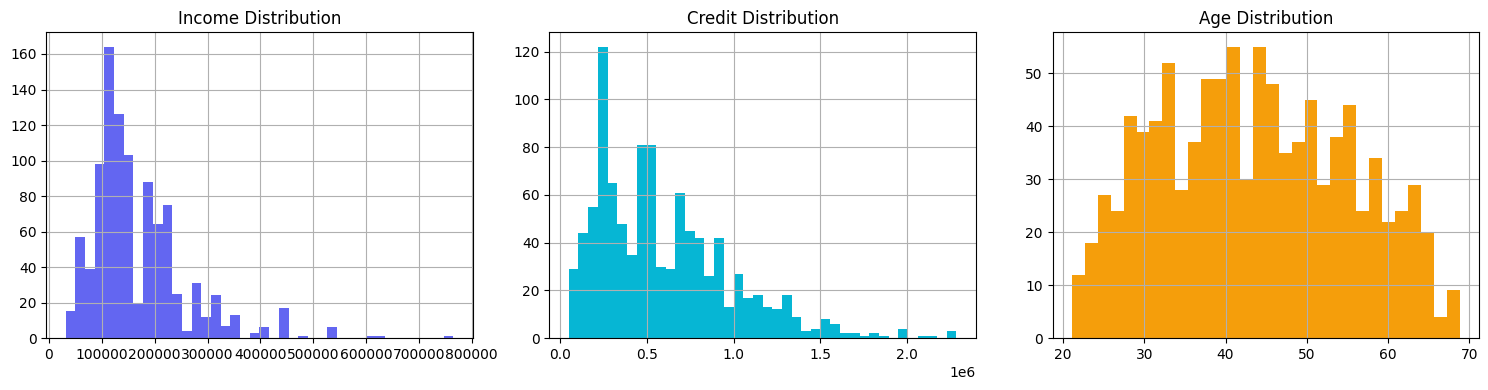

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df["AMT_INCOME_TOTAL"].hist(bins=40, ax=axes[0], color="#6366F1"); axes[0].set_title("Income Distribution")
df["AMT_CREDIT"].hist(bins=40, ax=axes[1], color="#06B6D4"); axes[1].set_title("Credit Distribution")
df["AGE_YEARS"].hist(bins=30, ax=axes[2], color="#F59E0B"); axes[2].set_title("Age Distribution")
plt.tight_layout(); plt.show()

In [4]:
df["NAME_EDUCATION_TYPE"].value_counts()

NAME_EDUCATION_TYPE
Secondary / secondary special    703
Higher education                 259
Incomplete higher                 29
Lower secondary                    9
Name: count, dtype: int64

In [5]:
df["OCCUPATION_TYPE"].value_counts().head(10)

OCCUPATION_TYPE
Laborers                 184
Sales staff              110
Core staff               107
Drivers                   72
Managers                  58
High skill tech staff     45
Medicine staff            31
Accountants               25
Cooking staff             18
Security staff            15
Name: count, dtype: int64

## Bivariate analysis

In [6]:
default_rate_by(df, "INCOME_GROUP")

,INCOME_GROUP,Customers,Defaults,Default Rate %
0,Very Low,200,11,5.5
1,Low,200,15,7.5
2,Middle,200,16,8.0
3,High,200,20,10.0
4,Very High,200,8,4.0


In [7]:
default_rate_by(df, "EMPLOYMENT_GROUP")

,EMPLOYMENT_GROUP,Customers,Defaults,Default Rate %
1,1-3 Years,198,16,8.08
3,5-10 Years,198,9,4.55
2,3-5 Years,163,12,7.36
4,10-20 Years,122,2,1.64
0,<1 Year,114,19,16.67
5,20+ Years,47,2,4.26


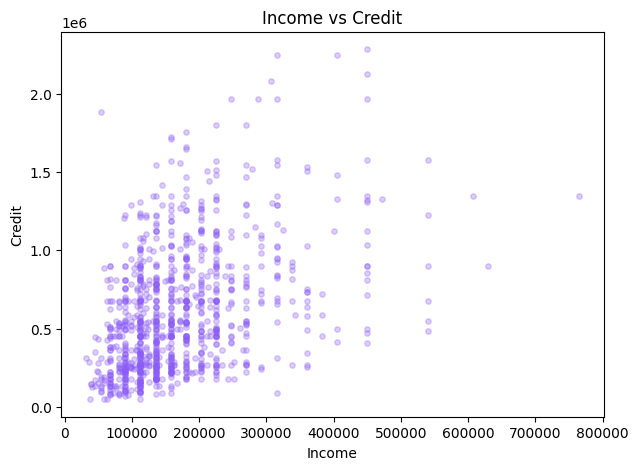

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["AMT_INCOME_TOTAL"], df["AMT_CREDIT"], alpha=0.3, c="#8B5CF6", s=15)
ax.set_xlabel("Income"); ax.set_ylabel("Credit"); ax.set_title("Income vs Credit")
plt.show()

In [9]:
default_rate_by(df, "CREDIT_TO_INCOME_BAND")

,CREDIT_TO_INCOME_BAND,Customers,Defaults,Default Rate %
1,Moderate (2-4),376,28,7.45
0,Low (<2),244,13,5.33
2,High (4-6),203,17,8.37
3,Very High (>6),177,12,6.78


## Multivariate analysis

In [10]:
# Age + Income + Default
df.groupby(["AGE_GROUP", "INCOME_GROUP"], observed=True)["TARGET"].mean().unstack().round(3)

INCOME_GROUP,Very Low,Low,Middle,High,Very High
AGE_GROUP,,,,,
20-30,0.111,0.088,0.156,0.167,0.042
31-40,0.053,0.104,0.088,0.089,0.067
41-50,0.023,0.048,0.058,0.109,0.015
51-60,0.018,0.100,0.000,0.086,0.049
60+,0.118,0.000,0.222,0.000,0.000


In [11]:
# Employment + Income + Default
df.groupby(["EMPLOYMENT_GROUP", "INCOME_GROUP"], observed=True)["TARGET"].mean().unstack().round(3)

INCOME_GROUP,Very Low,Low,Middle,High,Very High
EMPLOYMENT_GROUP,,,,,
<1 Year,0.071,0.211,0.176,0.286,0.091
1-3 Years,0.062,0.095,0.098,0.085,0.056
3-5 Years,0.036,0.038,0.103,0.154,0.045
5-10 Years,0.050,0.079,0.021,0.044,0.043
10-20 Years,0.000,0.000,0.040,0.042,0.000
20+ Years,0.000,0.000,0.222,0.000,0.000


In [12]:
# Education + Income + Default
df.groupby(["NAME_EDUCATION_TYPE", "INCOME_GROUP"], observed=True)["TARGET"].mean().unstack().round(3)

INCOME_GROUP,Very Low,Low,Middle,High,Very High
NAME_EDUCATION_TYPE,,,,,
Higher education,0.094,0.000,0.000,0.070,0.021
Incomplete higher,0.000,0.000,0.111,0.000,0.167
Lower secondary,0.000,0.000,0.000,0.000,0.000
Secondary / secondary special,0.049,0.096,0.099,0.118,0.051


## Correlation with TARGET (numeric factors)

Correlation describes an observed relationship, not causation.

In [13]:
factors = ["TARGET", "AGE_YEARS", "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY",
           "EMPLOYMENT_YEARS", "CNT_FAM_MEMBERS", "CREDIT_TO_INCOME", "ANNUITY_TO_INCOME",
           "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
corr = correlation_with_target(df, factors)
corr

ANNUITY_TO_INCOME    0.055359
CREDIT_TO_INCOME     0.043351
AMT_ANNUITY          0.024523
AMT_CREDIT           0.008376
CNT_FAM_MEMBERS     -0.004398
AMT_INCOME_TOTAL    -0.007218
AGE_YEARS           -0.082724
EMPLOYMENT_YEARS    -0.118483
EXT_SOURCE_1        -0.126033
EXT_SOURCE_2        -0.195020
EXT_SOURCE_3        -0.236136
Name: TARGET, dtype: float64

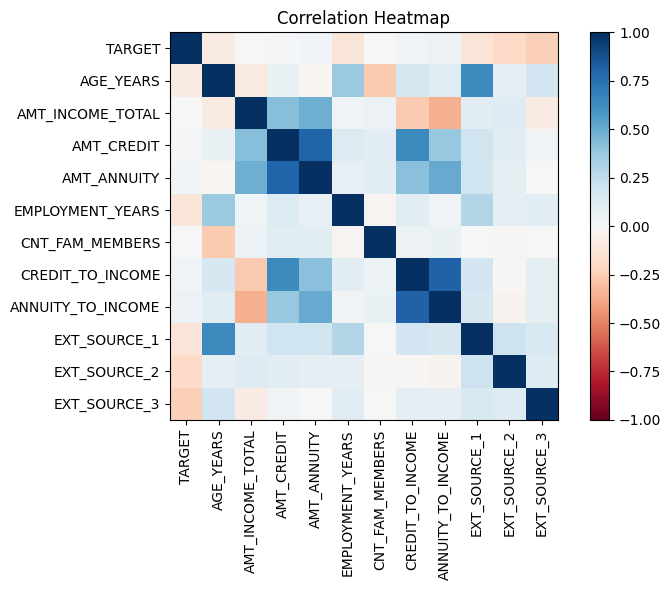

In [14]:
corr_matrix = df[[c for c in factors if c in df.columns]].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap="RdBu", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns))); ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticks(range(len(corr_matrix.columns))); ax.set_yticklabels(corr_matrix.columns)
plt.colorbar(im); plt.title("Correlation Heatmap"); plt.tight_layout(); plt.show()

## Count vs rate — a key EDA distinction

In [15]:
age_summary = df.dropna(subset=["AGE_GROUP"]).groupby("AGE_GROUP", observed=True).agg(
    customers=("TARGET", "size"), defaults=("TARGET", "sum")
)
age_summary["default_rate_pct"] = (age_summary["defaults"] / age_summary["customers"] * 100).round(2)
age_summary

,customers,defaults,default_rate_pct
AGE_GROUP,,,
20-30,147,17,11.56
31-40,270,22,8.15
41-50,269,14,5.20
51-60,222,11,4.95
60+,92,6,6.52


The age group with the **most defaults in absolute count** is not necessarily the age group
with the **highest default rate** — a large group can contain many defaults simply because it
contains many customers. Both numbers are reported together throughout the dashboard for this
reason.

## Summary

This notebook, together with 01-03, documents the full EDA & preprocessing pipeline that
feeds the 20-page Streamlit dashboard in `../pages/`. See `../README.md` for major insights
and business recommendations synthesized across all pages.